In [1]:
%pip install seaborn

Распределение классов:
churn
False    0.855086
True     0.144914
Name: proportion, dtype: float64

Classification Report (DecisionTreeClassifier):
              precision    recall  f1-score   support

       Loyal       0.95      0.95      0.95       709
     Churned       0.72      0.74      0.73       125

    accuracy                           0.92       834
   macro avg       0.84      0.84      0.84       834
weighted avg       0.92      0.92      0.92       834



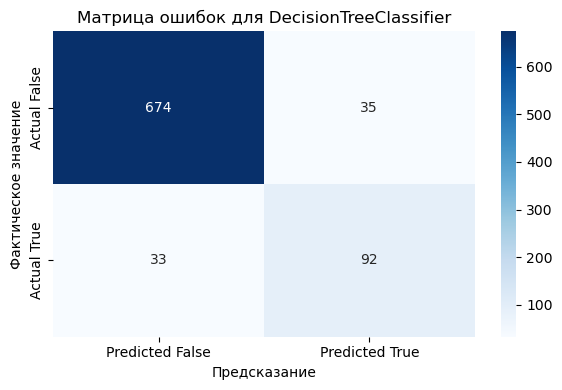


Classification Report (DecisionTreeClassifier с class_weight='balanced'):
              precision    recall  f1-score   support

       Loyal       0.95      0.94      0.95       709
     Churned       0.69      0.72      0.71       125

    accuracy                           0.91       834
   macro avg       0.82      0.83      0.83       834
weighted avg       0.91      0.91      0.91       834


Лучшие параметры: {'classifier__criterion': 'entropy', 'classifier__max_depth': 10, 'classifier__min_samples_split': 2}
Лучший результат кросс-валидации (F1): 0.7034097028440411

Classification Report (Финальная модель):
              precision    recall  f1-score   support

       Loyal       0.95      0.94      0.95       709
     Churned       0.69      0.72      0.70       125

    accuracy                           0.91       834
   macro avg       0.82      0.83      0.82       834
weighted avg       0.91      0.91      0.91       834



<Figure size 640x480 with 0 Axes>

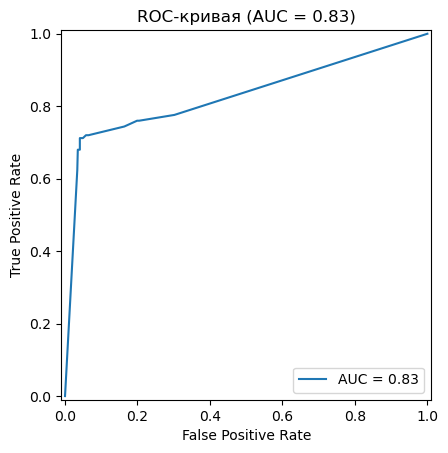


Важность признаков (только ненулевые):
               Feature   Importance
      total day charge 1.616816e-01
 international plan_no 1.273251e-01
customer service calls 1.055873e-01
     total day minutes 1.039918e-01
      total intl calls 8.145782e-02
     total night calls 6.265885e-02
      total eve charge 5.240627e-02
   total night minutes 5.159058e-02
     total eve minutes 4.778321e-02
     total intl charge 4.391515e-02
   voice mail plan_yes 3.025505e-02
    total night charge 2.617191e-02
        account length 2.000716e-02
international plan_yes 2.000085e-02
       total eve calls 1.668746e-02
       total day calls 1.315782e-02
    total intl minutes 1.297115e-02
              state_NJ 7.212316e-03
              state_WY 4.484847e-03
              state_DC 4.119149e-03
 number vmail messages 2.885784e-03
              state_WI 2.206631e-03
              state_MT 1.442166e-03
              state_SC 9.738642e-17
              state_CO 2.716925e-17
              state_OK 1

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_curve,
    auc,
    RocCurveDisplay,
    precision_score,
    recall_score,
    f1_score
)


data = pd.read_csv('telecom_churn(1).csv')

print("Распределение классов:")
print(data['churn'].value_counts(normalize=True))


X = data.drop('churn', axis=1)
y = data['churn']

categorical_features = ['state', 'international plan', 'voice mail plan']
numerical_features = [col for col in X.columns if col not in categorical_features and col!='phone number']


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])
dt_pipeline.fit(X_train, y_train)
y_pred_dt = dt_pipeline.predict(X_test)

print("\nClassification Report (DecisionTreeClassifier):")
print(classification_report(y_test, y_pred_dt, target_names=['Loyal', 'Churned']))

cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted False', 'Predicted True'],
            yticklabels=['Actual False', 'Actual True'])
plt.title(f'Матрица ошибок для DecisionTreeClassifier')
plt.xlabel('Предсказание')
plt.ylabel('Фактическое значение')
plt.tight_layout()
plt.show()

dt_balanced_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(class_weight='balanced', random_state=42))
])
dt_balanced_pipeline.fit(X_train, y_train)
y_pred_dt_balanced = dt_balanced_pipeline.predict(X_test)

print("\nClassification Report (DecisionTreeClassifier с class_weight='balanced'):")
print(classification_report(y_test, y_pred_dt_balanced, target_names=['Loyal', 'Churned']))

param_grid = {
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_split': [2, 5],
    'classifier__criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(
    estimator=dt_balanced_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print("\nЛучшие параметры:", best_params)
print("Лучший результат кросс-валидации (F1):", best_score)

final_model = grid_search.best_estimator_
final_model.fit(X_train, y_train)
y_pred_final = final_model.predict(X_test)

print("\nClassification Report (Финальная модель):")
print(classification_report(y_test, y_pred_final, target_names=['Loyal', 'Churned']))

y_proba_final = final_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba_final, pos_label=True)
roc_auc = auc(fpr, tpr)

plt.figure()
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc).plot()
plt.title('ROC-кривая (AUC = %0.2f)' % roc_auc)
plt.show()

if hasattr(final_model.named_steps['classifier'], 'feature_importances_'):
    ohe_feature_names = final_model.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
    all_feature_names = numerical_features + list(ohe_feature_names)
    importances = final_model.named_steps['classifier'].feature_importances_
    feature_importance = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
    feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

    feature_importance = feature_importance[feature_importance['Importance'] > 0]

    print("\nВажность признаков (только ненулевые):")
    print(feature_importance.to_string(index=False))


In [3]:
    
def get_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision (Churned)': precision_score(y_true, y_pred, pos_label=1),
        'Recall (Churned)': recall_score(y_true, y_pred, pos_label=1),
        'F1 (Churned)': f1_score(y_true, y_pred, pos_label=1)
    }

old_metrics = get_metrics(y_test, y_pred_dt)
new_metrics = get_metrics(y_test, y_pred_final)

comparison = pd.DataFrame({'Базовая модель': old_metrics, 'Финальная модель': new_metrics})
print("\nСравнение метрик:")
print(comparison)


Сравнение метрик:
                     Базовая модель  Финальная модель
Accuracy                   0.918465          0.908873
Precision (Churned)        0.724409          0.687023
Recall (Churned)           0.736000          0.720000
F1 (Churned)               0.730159          0.703125


**Для бизнеса важнее fn**